Converts MIDI file to matrix of pitches and times

In [2]:
import os.path
import numpy as np
import matplotlib.pyplot as plt
import pretty_midi

In [3]:
def midi_to_matrix(filepath, fs, onset_model=False):
    # Load MIDI file
    midi_data = pretty_midi.PrettyMIDI(filepath)
    
    # Combine all instruments into one piano roll
    piano_roll = midi_data.get_piano_roll(fs=fs, pedal_threshold=0)
    piano_roll = piano_roll[20:108, :]

    if onset_model:
        # Create an empty array
        onsets = np.zeros_like(piano_roll, dtype=np.uint8)
        
        # For each note row, detect onsets (where velocity changes from 0 to >0)
        for note in range(piano_roll.shape[0]):
            velocity = piano_roll[note]
            onsets[note, 1:] = ((velocity[1:] > 0) & (velocity[:-1] == 0)).astype(np.uint8)
            onsets[note, 0] = (velocity[0] > 0).astype(np.uint8)  # Edge case for first frame
            
        return onsets
    
    else:
        binary_roll = (piano_roll > 0).astype(np.uint8)
        return binary_roll

In [4]:
dir = 'midi'
xml_dir = 'xml_features'

# file = 'bach_fugue_bwv_846.mid'
# xml = 'onsetbach_fugue_bwv_846.musicxml.npz'

file = 'schumann_arabeske_park.mid'
xml = 'schumann_arabeske.musicxml.npz'

# file = 'brahms_Shilyaev03.mid'
# xml = 'onsetbrahms.musicxml.npz'

# file = 'glinka.mid'
# xml = 'onsetglinka.musicxml.npz'

# file = 'Beethoven-Chen.mid'
# xml = 'onsetBeethovem-30-1.musicxml.npz'

# file = 'Chopin-LeeKoeun.mid'
# xml = 'onsetChopin-Ballades-1.musicxml.npz'

# file = 'debussy.mid'
# xml = 'onsetdebussy.musicxml.npz'

# file = 'Haydn-6-1.mid'
# xml = 'onsetHaydn-6-1.musicxml.npz'

# file = 'liszt_concert_etude_s145_Kleisen03.mid'
# xml = 'onsetliszt_concert_etude_s145_1.musicxml.npz'

# file = 'Mozart-fantasie.mid'
# xml = 'onsetMozart-Fantasie.musicxml.npz'

# file = 'Prokofiev-Toccata.mid'
# xml = 'onsetProkofiev-Toccata.musicxml.npz'

# file = 'Ravel.mid'
# xml = 'onsetRavel.musicxml.npz'

filepath = os.path.join(dir, file)
xml_filepath = os.path.join(xml_dir, xml)

# determine fs based on length of xml_features
xml_data = np.load(xml_filepath)
xml_frames = xml_data['measure_boundaries'][-1]

print(xml_frames)

8212


In [9]:
midi_frames = 0
fs = 1
roll = midi_to_matrix(filepath, fs, onset_model=False)

while midi_frames < xml_frames*0.95:
    fs += 1
    midi_frames = roll.shape[1]
    roll = midi_to_matrix(filepath, fs, onset_model=False)
    print(fs)

2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


In [10]:
# np.savez(os.path.join('midi_features', 'onset'+file), roll=roll, fs=fs)
# np.savez(os.path.join('midi_features', file), roll=roll, fs=fs)
print(roll.shape)

(88, 8310)


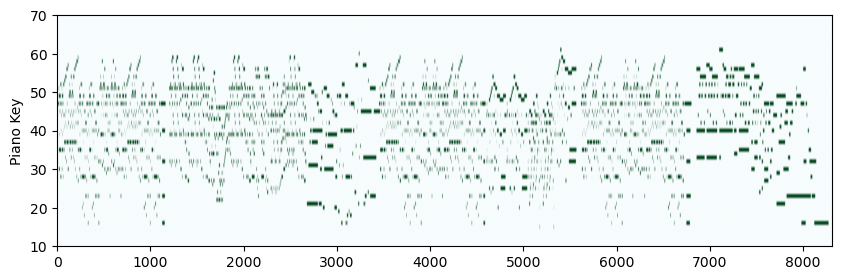

In [14]:
plt.figure(figsize=(10,3))
plt.imshow(roll, cmap = 'BuGn', origin = 'lower', aspect='auto', interpolation=None)
plt.ylabel('Piano Key')
plt.ylim(10,70)
plt.show()